### Obtaining the geometry of the snapshot box for generating lightcones


Author: Soumya Shreeram

Date: 2th March
 2023

Contact: shreeram@mpe.mpg.de


In [1]:
import numpy as np
import os
import sys

# plotting imports
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
# other imports
from astropy.cosmology import Planck15 as cosmo
from astropy import units as u
from astropy.table import QTable

In [2]:
mpl.rcParams['agg.path.chunksize'] = 100000
%matplotlib inline
font = {'family' : "sans-serif",
'weight' : 'medium',
'size'   : 18}
mpl.rc('font', **font)

In [3]:
%load_ext autoreload
%autoreload 2

Checking how the faces of the cube are defined

In [ ]:
os.chdir(f"{os.getcwd()}/../src/")

from remap_IllustrisTNG import Lightcone_IllustrisTNG
from tools import plotting as pt
from util import cartesian2polar

soxs : [WARNING  ] 2024-09-04 09:56:44,545 Setting 'soxs_data_dir' to /u/soumyashreeram/.cache/soxs for this session. Please update your configuration if you want it somewhere else.


In [9]:
lightcone_subhalo = Lightcone_IllustrisTNG(particle_type = 'Subhalo')
pos = lightcone_subhalo.get_particles_coord()
plt.rcParams['font.family'] = 'sans-serif'

Now we test the new class used to get the opening angles of the lighcone. 

We start by getting the verticies of the cuboid.

In [6]:
Lx, Ly, Lz = 4.1231, 0.7276, 0.3333
verticies = cgm.util.form_verticies(Lx, Ly, Lz)

We create a box, and use the coordinates to obtain the faces and edges of this cuboid.

In [7]:
box = cgm.get_geometry.MakeCuboid(verticies=verticies)
faces = box.get_faces()
edges = box.cuboid_edges()

<function isdir at 0x1494fdfc38b0>


We obtain the intersection between the `bottom face` and the `front_edges[2]` and `back_edges[2]`. In this case we are on the X-Y plane.

Representation of a cuboid <br>
```python
    :               (2)--------(δ)-----(6)
    :              / |                / |
    :           (4)-------------(γ)-(7) |                     
    :            |   |               |  |
    :            |  (1)----------(β)-|-(5)
    :            |  /                | /
    :            (3)----------------(α)
```

### 1) Back face, botton edge intersection (X- Y plane with Z=0)

In [8]:
solver = cgm.get_geometry.Geometry(verticies=verticies, sphere_radius=Lx)
x_roots = solver.circle_line_intersection(center=(0, 0), line_param=(0, Ly))
beta = x_roots[1]
print(x_roots, f"{beta=:.2f}")

<function isdir at 0x1494fdfc38b0>
[-4.05839277  4.05839277] beta=4.06


### 2) Front face, top edge intersection (X-Z plane with Y=0)

In [9]:
x_roots2 = solver.circle_line_intersection(center=(0, 0), line_param=(0, Lz))
gamma = x_roots2[1]
print(x_roots2, f"{gamma=:.2f}")

[-4.10960639  4.10960639] gamma=4.11


### 3) Back face, top edge intersection (X-Y plane with Z=Lz and radius= $\delta$)

In [10]:
x_roots3 = solver.circle_line_intersection(r = x_roots[0], center=(0, Lz), line_param=(0, Ly))
delta = x_roots3[1] 
print(x_roots3, f"{delta=:.2f}")

[-4.03919291  4.03919291] delta=4.04


In [11]:
alpha = Lx

In [12]:
print(f"{alpha=:.2f}, {beta=:.2f}, {gamma=:.2f}, {delta=:.2f}")

alpha=4.12, beta=4.06, gamma=4.11, delta=4.04


### Obtaining the opening angles

So the two opening angles for the observer at $o = (0, 0, 0)$ are $\angle \rm \alpha o \beta$  and $\angle \rm \alpha o \gamma$

In [13]:
vec1 = [beta, Ly]
vec2 = [alpha, 0]
vec3 = [gamma, Lz]

theta = cgm.util.get_angle(vec1, vec2)*u.deg
phi = cgm.util.get_angle(vec3, vec2)*u.deg
print(f"{theta=:.4f}, {phi=:.4f}")

theta=10.1642 deg, phi=4.6367 deg


for consistency we also check the angle $\angle \beta o \delta$ and $\angle \gamma o \delta$:

In [14]:
ang1 = cgm.util.get_angle([beta, 0], [delta, Lz])*u.deg
ang2 = cgm.util.get_angle([gamma, 0], [delta, Ly])*u.deg
print(f"{ang1=:.2f}, {ang2=:.2f}")

ang1=4.72 deg, ang2=10.21 deg


In [15]:
area = cgm.util.area_rectangle_on_sphere(theta.value, phi.value)
area*(u.deg*u.deg)

<Quantity 47.27799174 deg2>

In [16]:
8*area*(u.deg*u.deg)

<Quantity 378.22393389 deg2>

In [17]:
solver.get_intersections()

INFO:Geometry:theta=10.16 deg, phi=4.64 deg, ang1=4.72 deg, ang2=10.21 deg


(<Quantity 10.16416558 deg>,
 <Quantity 4.63669159 deg>,
 <Quantity 4.71715935 deg>,
 <Quantity 10.21146553 deg>,
 {'alpha': 4.1231,
  'beta': -4.058392766847486,
  'gamma': -4.1096063947779715,
  'delta': -4.0391929094808035})

### Plot the lightcone that you just created

Note: here the ligthcone is created for the boxremap solution (Lx, Ly, Lz) = (4.1231, 0.7276, 0.3333)

You could do the same for any other solution and then accordingly decide out to which redshift you need to go to put it all together.

In [7]:
# load the files
snapshot_list = np.arange(78, 100).astype(str)
shell_id_arr = []
radial_coord = []
cart_coord = []
for snapshot in snapshot_list[:-3]:
    lightcone_subhalo = Lightcone_IllustrisTNG(particle_type = 'Subhalo', snap_nr= snapshot)

    # remap the particles  
    Lx, Ly, Lz = 4.1231, 0.7276, 0.3333
    lightcone_subhalo.get_filenames()

    # save filenames
    shell_id_arr.append(lightcone_subhalo.shell_ids)
    radial_coord.append(lightcone_subhalo.spherical_remapped_coords)
    cart_coord.append(lightcone_subhalo.remapped_coords)

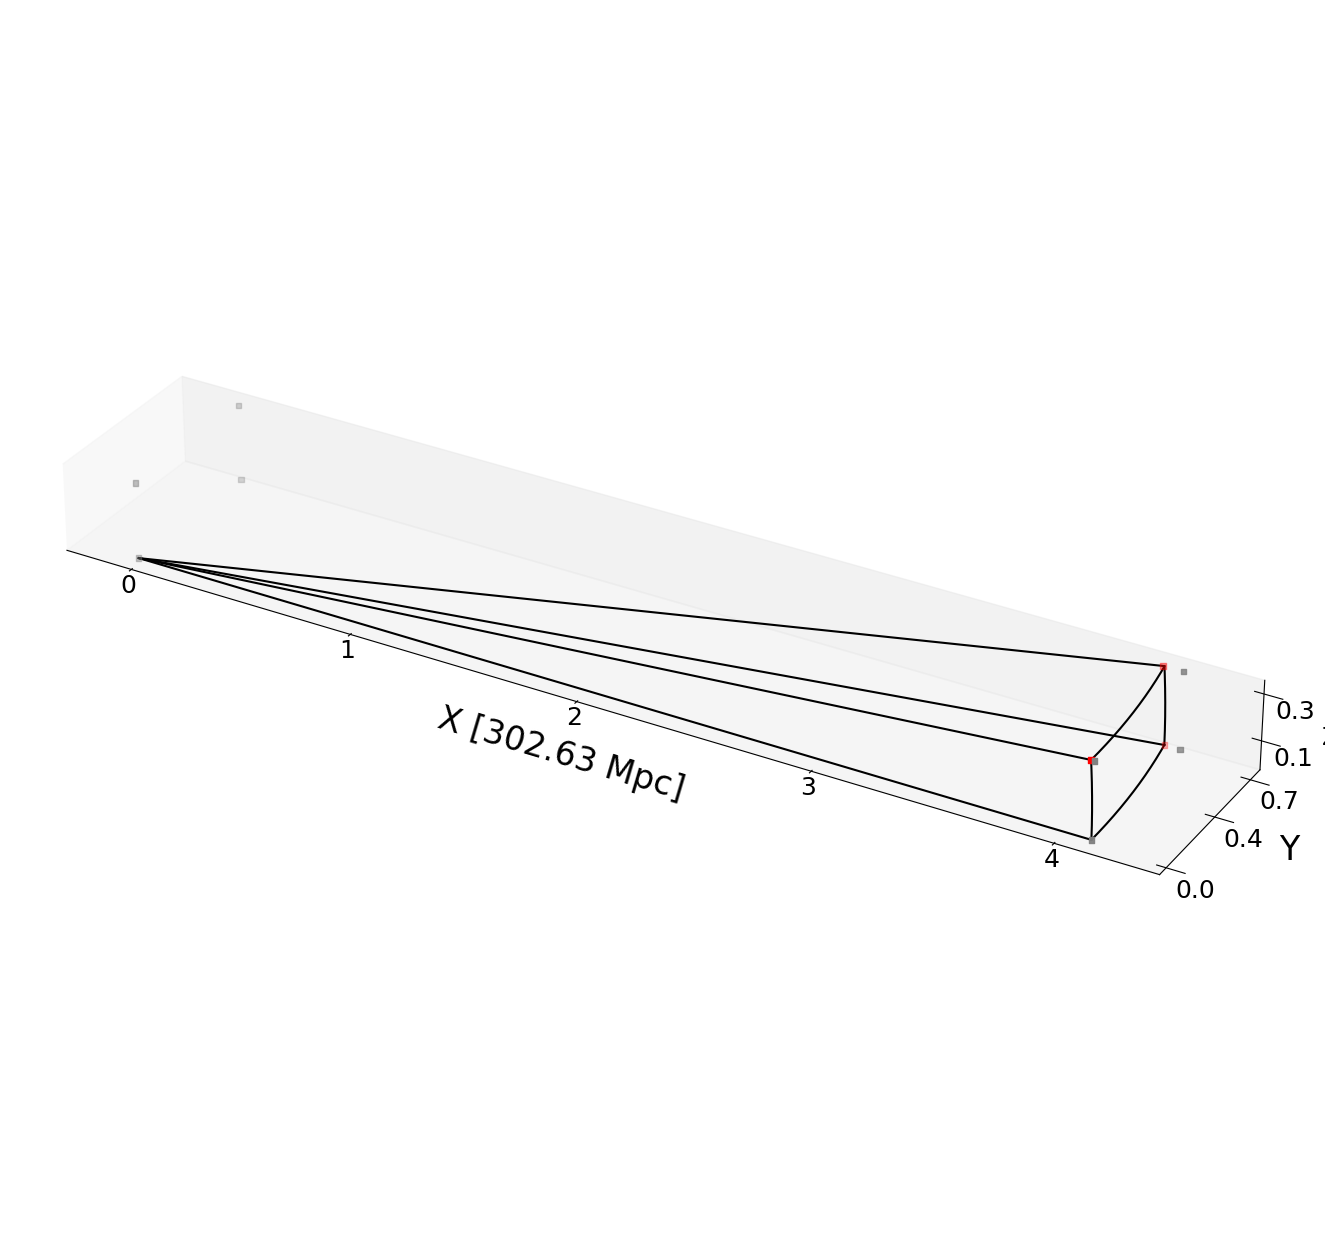

In [60]:
fig = plt.figure(figsize=(16, 25)) 
ax = plt.axes(projection='3d')

pt.set_labels(ax, f'X [{lightcone_subhalo.boxsize:.2f}]', 'Y', labelpad=[100, 10, 1])
ax.set_yticks([0, np.round(Ly/2, 1), np.round(Ly, 1)])
ax.set_zticks([np.round(Lz/3, 1), np.round(Lz, 1)])

ax.set_zlabel('Z' )
ax.set_box_aspect((Lx, Ly, Lz))

# plot the edges estimated by simply getting the min/max in (x, y, z)
remapped_coords = np.load(lightcone_subhalo.remapped_coords, allow_pickle=True)
edges_re = cgm.util.get_edges(remapped_coords)

ax.scatter3D(edges_re[:, 0], edges_re[:, 1], edges_re[:, 2], marker='s', c='grey', s=15)

# plot beta=[beta, Ly, 0], gamma=[gamma, 0, Lz], delta=[delta, Ly, Lz]
ax.scatter3D([beta, gamma, delta], [Ly, 0, Ly], [0, Lz, Lz], marker='s', c='r', s=15)
for a in np.array([ [alpha, 0, 0], [beta, Ly, 0], [gamma, 0, Lz], [delta, Ly, Lz]]):
    b = np.array([0, 0, 0])
    b = np.vstack((b, a))
    ax.plot(b[:, 0], b[:, 1], b[:, 2], 'k-')

# plot the circles
theta_arr, phi_arr = np.linspace(0, np.deg2rad(theta.value), 200), np.linspace(0, np.deg2rad(phi.value), 200)
ang1_arr, ang2_arr = np.linspace(0, np.deg2rad(ang1.value), 200), np.linspace(0, np.deg2rad(ang2.value), 200)
ax.plot(alpha*np.cos(theta_arr), alpha*np.sin(theta_arr), np.zeros(len(theta_arr)), 'k-')
ax.plot( alpha*np.cos(phi_arr), np.zeros(len(phi_arr)), alpha*np.sin(phi_arr), 'k-')
ax.plot( beta*np.cos(ang1_arr), Ly*np.ones(len(ang1_arr)), beta*np.sin(ang1_arr), 'k-')
ax.plot( gamma*np.cos(ang2_arr), gamma*np.sin(ang2_arr), Lz*np.ones(len(ang2_arr)),'k-') 


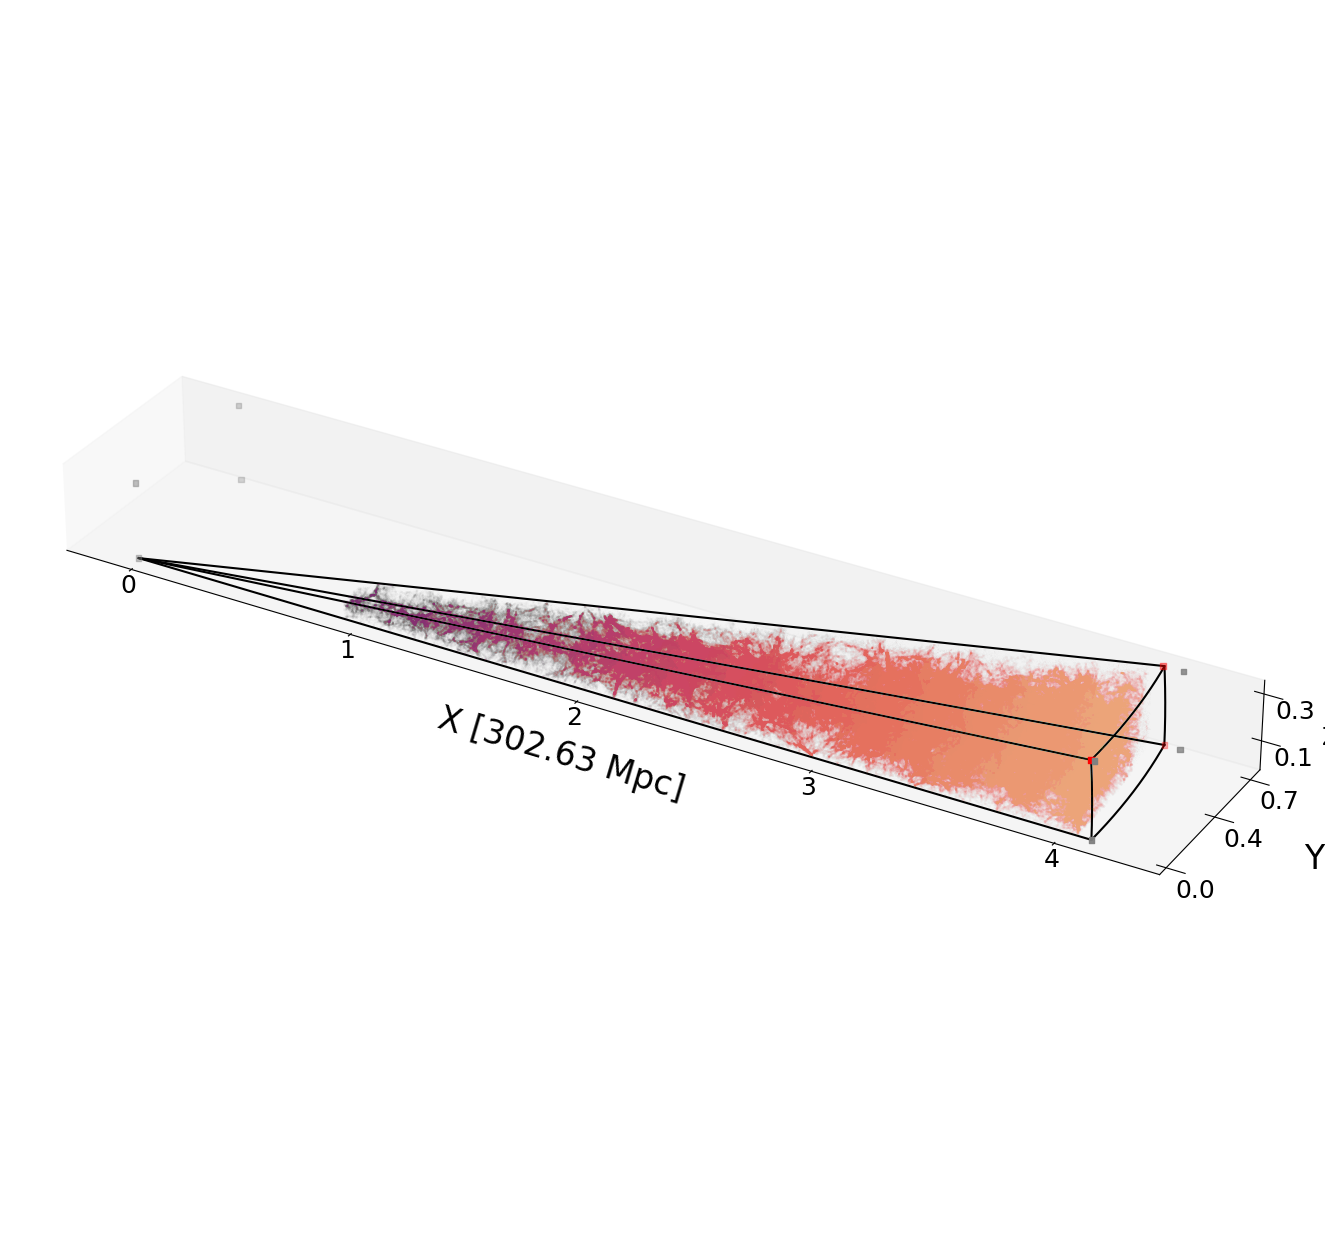

In [23]:
fig = plt.figure(figsize=(16, 25))
ax = plt.axes(projection='3d')
c_list = sns.color_palette("flare", len(shell_id_arr)).as_hex()
for i, (id_names, coord_names) in enumerate(zip(shell_id_arr, cart_coord)):

    ids = np.load(id_names, allow_pickle=True)

    coord = np.load(coord_names, allow_pickle=True)

    x, y, z = coord[ids, 0], coord[ids, 1], coord[ids, 2]
    lc = ax.scatter3D(x, y, z, c=c_list[i], s=1e-5)
pt.set_labels(ax, f'X [{lightcone_subhalo.boxsize:.2f}]', 'Y', labelpad=[100, 20, 20])
ax.set_yticks([0, np.round(Ly/2, 1), np.round(Ly, 1)])
ax.set_zticks([np.round(Lz/3, 1), np.round(Lz, 1)])

ax.set_zlabel('Z')
ax.set_box_aspect((Lx, Ly, Lz))

# plot the edges estimated by simply getting the min/max in (x, y, z)
remapped_coords = np.load(lightcone_subhalo.remapped_coords, allow_pickle=True)
edges_re = cgm.util.get_edges(remapped_coords)

ax.scatter3D(edges_re[:, 0], edges_re[:, 1], edges_re[:, 2], marker='s', c='grey', s=15)

# plot beta=[beta, Ly, 0], gamma=[gamma, 0, Lz], delta=[delta, Ly, Lz]
ax.scatter3D([beta, gamma, delta], [Ly, 0, Ly], [0, Lz, Lz], marker='s', c='r', s=15)
for a in np.array([ [alpha, 0, 0], [beta, Ly, 0], [gamma, 0, Lz], [delta, Ly, Lz]]):
    b = np.array([0, 0, 0])
    b = np.vstack((b, a))
    ax.plot(b[:, 0], b[:, 1], b[:, 2], 'k-')

# plot the circles
theta_arr, phi_arr = np.linspace(0, np.deg2rad(theta.value), 200), np.linspace(0, np.deg2rad(phi.value), 200)
ang1_arr, ang2_arr = np.linspace(0, np.deg2rad(ang1.value), 200), np.linspace(0, np.deg2rad(ang2.value), 200)
ax.plot(alpha*np.cos(theta_arr), alpha*np.sin(theta_arr), np.zeros(len(theta_arr)), 'k-')
ax.plot( alpha*np.cos(phi_arr), np.zeros(len(phi_arr)), alpha*np.sin(phi_arr), 'k-')
ax.plot( beta*np.cos(ang1_arr), Ly*np.ones(len(ang1_arr)), beta*np.sin(ang1_arr), 'k-')
ax.plot( gamma*np.cos(ang2_arr), gamma*np.sin(ang2_arr), Lz*np.ones(len(ang2_arr)),'k-') 


Gathering the quantities required for doing the 3D plot

In [35]:
from cgmsim.tools import illustris_python as il
mass_all, shell_ids_all, coords_all = np.array([]), np.array([]), np.zeros(shape=(0,3))
for i, (id_names, coord_names) in enumerate(zip(shell_id_arr, cart_coord)):
    lightcone_subhalo = Lightcone_IllustrisTNG(particle_type = 'Subhalo', snap_nr= snapshot_list[i])

    old_ids = np.load(id_names, allow_pickle=True)
    old_coord = np.load(coord_names, allow_pickle=True)

    flag = il.groupcat.loadSubhalos(lightcone_subhalo.sim_data_dir, lightcone_subhalo.snap_nr, fields=['SubhaloFlag'])[old_ids]
    ids = old_ids[flag]
    coord = old_coord[old_ids][flag]

    # SubhaloMassInRadType
    mass = il.groupcat.loadSubhalos(lightcone_subhalo.sim_data_dir, lightcone_subhalo.snap_nr, fields=['SubhaloMassInRadType'])[ids, 4]
    print(len(mass), len(ids), len(coord))

    mass_all = np.append(mass_all, mass)
    shell_ids_all = np.append(shell_ids_all, ids)
    coords_all = np.append(coords_all, coord, axis=0)

673110 673110 673110
800485 800485 800485
482294 482294 482294
514716 514716 514716
491378 491378 491378
260623 260623 260623
300700 300700 300700
339836 339836 339836
297025 297025 297025
200186 200186 200186
126204 126204 126204
104895 104895 104895
98759 98759 98759
81383 81383 81383
48516 48516 48516
24258 24258 24258
27019 27019 27019
28148 28148 28148
12916 12916 12916


In [54]:
print(len(shell_ids_all), len(mass_all), len(coords_all))
shell_ids_all = shell_ids_all.astype(int)

select = (mass_all > 0)
print(len(shell_ids_all[select]), len(mass_all[select]), len(coords_all[select]))
shell_ids_all = shell_ids_all[select]
mass_all = mass_all[select]
coords_all = coords_all[select]

4912451 4912451 4912451
424415 424415 424415


In [137]:
mass_all_logged = (mass_all/lightcone_subhalo.h)*1e10

In [83]:
np.mean(mass_all_logged), np.max(mass_all_logged), np.min(mass_all_logged)

(8.19690587391781, 12.362773713890116, 6.291587286339148)

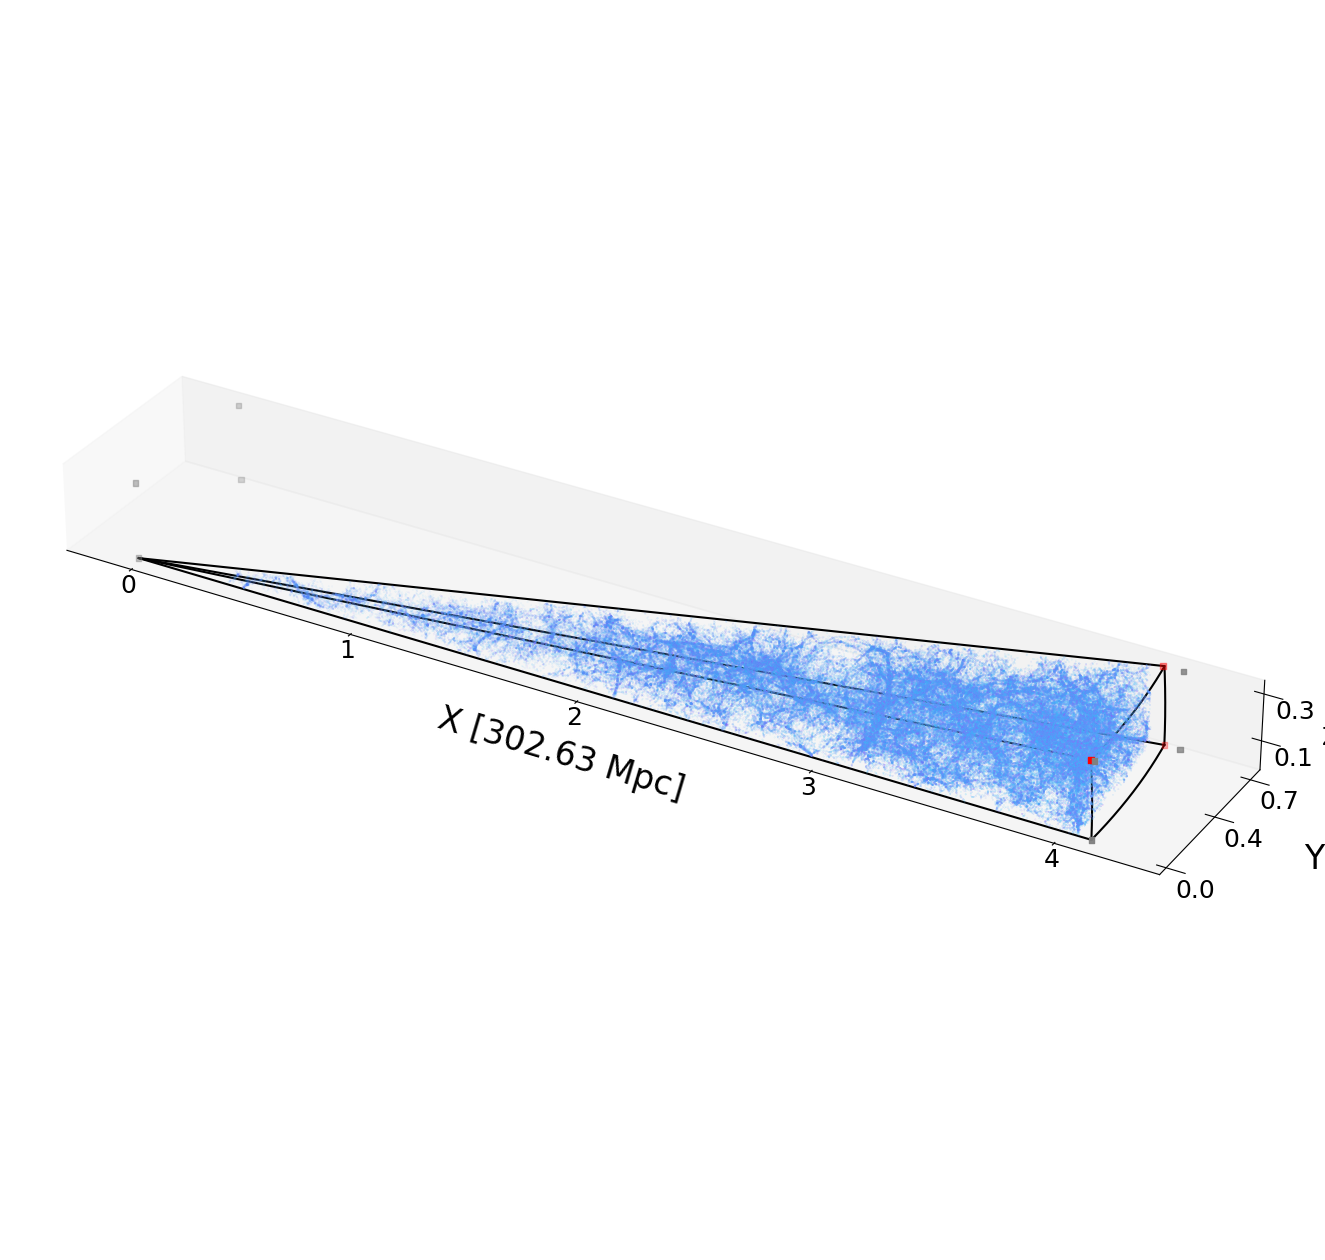

In [ ]:
fig = plt.figure(figsize=(16, 25))
ax = plt.axes(projection='3d')

x, y, z = coords_all[:, 0], coords_all[:, 1], coords_all[:, 2]
lc = ax.scatter3D(x, y, z, c=mass_all_logged, cmap='cool', s=5e-3, norm='log')
pt.set_labels(ax, f'X [{lightcone_subhalo.boxsize:.2f}]', 'Y', labelpad=[100, 20, 20])
ax.set_yticks([0, np.round(Ly/2, 1), np.round(Ly, 1)])
ax.set_zticks([np.round(Lz/3, 1), np.round(Lz, 1)])

ax.set_zlabel('Z')
ax.set_box_aspect((Lx, Ly, Lz))

# plot the edges estimated by simply getting the min/max in (x, y, z)
remapped_coords = np.load(lightcone_subhalo.remapped_coords, allow_pickle=True)
edges_re = cgm.util.get_edges(remapped_coords)

ax.scatter3D(edges_re[:, 0], edges_re[:, 1], edges_re[:, 2], marker='s', c='grey', s=15)

# plot beta=[beta, Ly, 0], gamma=[gamma, 0, Lz], delta=[delta, Ly, Lz]
ax.scatter3D([beta, gamma, delta], [Ly, 0, Ly], [0, Lz, Lz], marker='s', c='r', s=15)
for a in np.array([ [alpha, 0, 0], [beta, Ly, 0], [gamma, 0, Lz], [delta, Ly, Lz]]):
    b = np.array([0, 0, 0])   
    b = np.vstack((b, a))
    ax.plot(b[:, 0], b[:, 1], b[:, 2], 'k-')

# plot the circles
theta_arr, phi_arr = np.linspace(0, np.deg2rad(theta.value), 200), np.linspace(0, np.deg2rad(phi.value), 200)
ang1_arr, ang2_arr = np.linspace(0, np.deg2rad(ang1.value), 200), np.linspace(0, np.deg2rad(ang2.value), 200)
ax.plot(alpha*np.cos(theta_arr), alpha*np.sin(theta_arr), np.zeros(len(theta_arr)), 'k-')
ax.plot( alpha*np.cos(phi_arr), np.zeros(len(phi_arr)), alpha*np.sin(phi_arr), 'k-')
ax.plot( beta*np.cos(ang1_arr), Ly*np.ones(len(ang1_arr)), beta*np.sin(ang1_arr), 'k-')
ax.plot( gamma*np.cos(ang2_arr), gamma*np.sin(ang2_arr), Lz*np.ones(len(ang2_arr)),'k-') 


In [90]:
def rotation_matrix(coords):
    rot_mat = np.array([[ 9.95253462e-01, -8.85106062e-02, -4.04526723e-02],
       [ 8.85831154e-02,  9.96068789e-01,  2.16840434e-19],
       [ 4.02936443e-02, -3.58342374e-03,  9.99181456e-01]])
    coord_rot =  coords @ rot_mat
    return coord_rot

In [ ]:
from matplotlib.colors import LogNorm, LinearSegmentedColormap

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

Text(0, 0.5, '$\\frac{M_\\star}{M_\\odot}$')

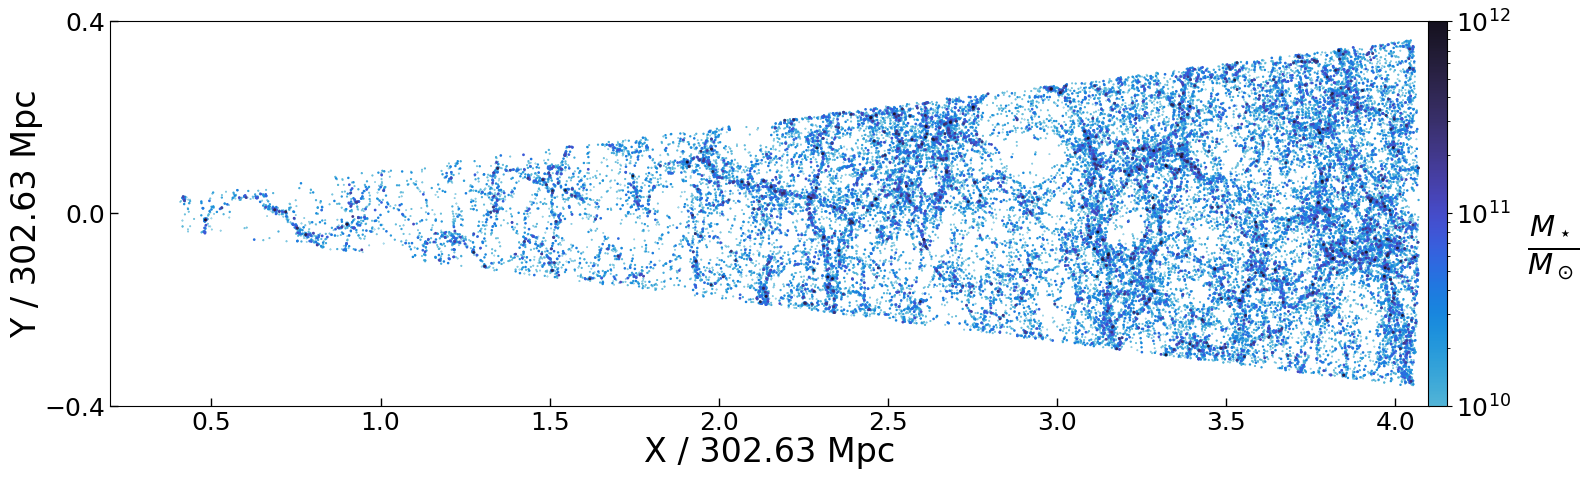

In [ ]:
select_mass = (10**9.5 < mass_all_logged) & (mass_all_logged <10**12.)

fig, ax = plt.subplots(1, 1, figsize=(20, 5))

coords_all_rot = rotation_matrix(coords_all[select_mass])
x, y, z = coords_all_rot[:, 0], coords_all_rot[:, 1], coords_all_rot[:, 2]

idssorted = np.argsort(np.log10(mass_all_logged[select_mass]))
mass_sorted = mass_all_logged[select_mass][idssorted]

rescale_factor = np.geomspace(0.1, 1, len(mass_sorted))*1e-1
size_arr = [(n*rescale_factor[i]) for i, n in enumerate(np.log10(mass_sorted))]

# cmap properties
vmin=1e10
vmax=1e12
cmap = mpl.colormaps.get_cmap('cmr.freeze_r')
new_cmap = truncate_colormap(cmap, 0.3, 0.9)
norm = LogNorm(vmin=vmin, vmax=vmax)

# scatter plot
lc = ax.scatter(x[idssorted], y[idssorted], c=mass_sorted,
                cmap=new_cmap,
                s=size_arr,
                norm=norm)

# setting labels and ticks
pt.set_labels(ax, f'X / {lightcone_subhalo.boxsize:.2f}', f'Y / {lightcone_subhalo.boxsize:.2f}',
              xlim=[0.2, 4.1],
              ylim=[-Ly/2, Ly/2]
              )
ax.set_yticks([0, np.round(-Ly/2, 1), np.round(Ly/2, 1)])

# generate colorbar
cbar = fig.colorbar(lc, pad=-0.001)
cbar.ax.set_ylabel(r'$\frac{M_\star}{M_\odot}$', rotation=0, fontsize=30,
                   labelpad=30
                   )


In [118]:
np.max(mass_all_logged[select_mass])

11.498814235275894

In [ ]:
# Add a color bar which maps values to colors.
lightcone_subhalo.snapshot2redshifts()
snapshot_info = pd.read_csv(lightcone_subhalo.snapshot_info_file, sep=' ', header=0)
redshift = snapshot_info['redshift'].to_numpy()
c_list = sns.color_palette("flare", len(shell_id_arr)).as_hex()
cmap = mpl.colors.ListedColormap(c_list)

bounds = np.flip(redshift)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
cb3 = mpl.colorbar.ColorbarBase(ax, cmap=cmap,
                                norm=norm,
                                ticks=bounds,
                                spacing='uniform',
                                orientation='horizontal')
cb3.set_label('Redshift')

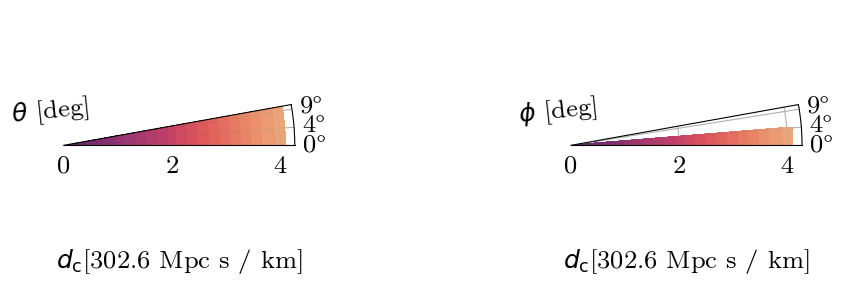

In [24]:
theta_max, phi_max = 10.16416,5.527474
fig, ax = plt.subplots(1, 2, figsize=(12, 3), subplot_kw={'projection': 'polar'})
for i, (id_names, coord_names) in enumerate(zip(shell_id_arr[:-1], radial_coord[:-1])):
    
    ids = np.load(id_names, allow_pickle=True)
    
    coord = np.load(coord_names, allow_pickle=True).T

    r, t, p = coord[ids, 0], coord[ids, 1], coord[ids, 2]
    ax[0].plot(t, r, 'o', c=c_list[i], ms=5e-2, alpha=0.8)
    ax[1].plot(p, r, 'o', c=c_list[i], ms=5e-2, alpha=0.8)

rlabel = r'$d_{\rm c}$'+f'[{lightcone_subhalo.boxsize:.1f}]'
theta_label = [r'$\theta$ [deg]', r'$\phi$ [deg]']
ax[0] = pt.set_polar_labels(ax[0], rlabel, theta_label[0], theta_lim=[0, theta_max])
ax[1] = pt.set_polar_labels(ax[1], rlabel, theta_label[1], theta_lim=[0, theta_max])

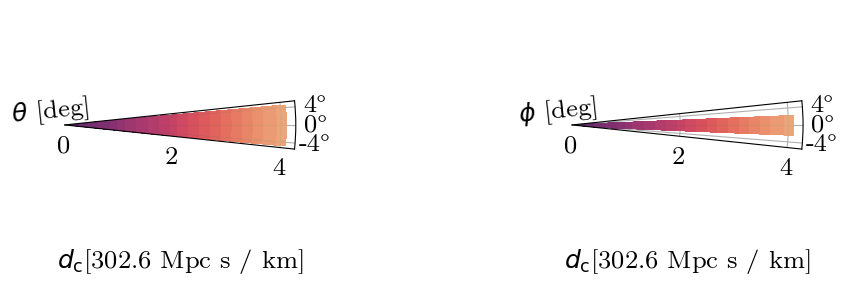

In [29]:
theta_max, phi_max = 10.16416,5.527474
fig, ax = plt.subplots(1, 2, figsize=(12, 3), subplot_kw={'projection': 'polar'})
for i, (id_names, coord_names) in enumerate(zip(shell_id_arr, cart_coord)):

    ids = np.load(id_names, allow_pickle=True)

    coord = np.load(coord_names, allow_pickle=True)
    coord = rotation_matrix(coord)
    r, t, p = cartesian2polar(coord[ids, 0], coord[ids, 1], coord[ids, 2])

    ax[0].plot(t, r, 'o', c=c_list[i], ms=5e-2, alpha=0.8)
    ax[1].plot(p, r, 'o', c=c_list[i], ms=5e-2, alpha=0.8)

rlabel = r'$d_{\rm c}$'+f'[{lightcone_subhalo.boxsize:.1f}]'
theta_label = [r'$\theta$ [deg]', r'$\phi$ [deg]']
ax[0] = pt.set_polar_labels(ax[0], rlabel, theta_label[0], theta_lim=[-theta_max/2, theta_max/2])
ax[1] = pt.set_polar_labels(ax[1], rlabel, theta_label[1], theta_lim=[-theta_max/2, theta_max/2])

Here you go! You have your subhalo lightcone. Of course, for the gas and DM lightcones, you need to run it on a server given the large data volumes. The code is also parallized to run it on chunks for gas cells and DM particles (see docs).